# 03 - Exploratory data analysis

Descriptive view of the cleaned corpus before any modelling: review length, language split, label balance, platform and entity coverage, temporal coverage and how much of each length band actually carries a service aspect. These feed the Dataset Overview tables and Figures 1-3 of the report.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# make src importable when the kernel starts inside notebooks/
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="notebook")
from src import config
from src.io import ensure_dirs, save_table, update_metrics, read_metrics
ensure_dirs()

In [2]:
from src.preprocessing import length_band
from src.aspects import add_aspect_columns, ASPECTS

df = pd.read_parquet(config.CLEAN_FILE)
df = add_aspect_columns(df)
df["tagged"] = df["n_aspects"] > 0
modelling = df[df.kept]
print(f"cleaned rows: {len(df):,}   modelling rows: {len(modelling):,}")

cleaned rows: 74,412   modelling rows: 48,930


## Review length

In [3]:
print(df.word_count.describe().round(1))
print(df.word_count.quantile([.25, .5, .75, .9, .95]))

bands = (df.groupby("length_band", observed=True)
           .agg(n=("review_id", "size"), aspect_carrying_pct=("tagged", "mean"))
           .assign(share_pct=lambda t: t.n / t.n.sum() * 100,
                   aspect_carrying_pct=lambda t: t.aspect_carrying_pct * 100)
           .round(1).reset_index())
save_table(bands, "eda_length_bands")
bands

count    74412.0
mean        15.2
std         17.0
min          0.0
25%          5.0
50%          9.0
75%         19.0
max        657.0
Name: word_count, dtype: float64
0.25     5.0
0.50     9.0
0.75    19.0
0.90    34.0
0.95    48.0
Name: word_count, dtype: float64


,length_band,n,aspect_carrying_pct,share_pct
0,0-2,5665,8.8,7.6
1,3-5,16107,25.7,21.6
2,6-10,18449,40.1,24.8
3,11-25,21787,58.8,29.3
4,26+,12404,78.6,16.7


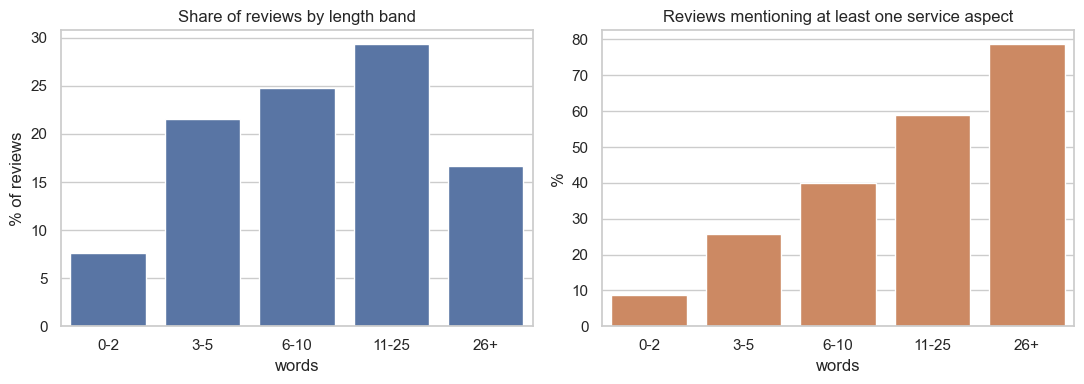

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=bands, x="length_band", y="share_pct", ax=ax[0], color="#4C72B0")
ax[0].set(title="Share of reviews by length band", xlabel="words", ylabel="% of reviews")
sns.barplot(data=bands, x="length_band", y="aspect_carrying_pct", ax=ax[1], color="#DD8452")
ax[1].set(title="Reviews mentioning at least one service aspect", xlabel="words", ylabel="%")
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / "fig_length_bands.png", dpi=200); plt.show()

## Language and label

In [5]:
lx = pd.crosstab(df.language, df.satisfaction_label.fillna("Neutral"), margins=True)
print("all cleaned rows"); print(lx); print()
lm = pd.crosstab(modelling.language, modelling.satisfaction_label, margins=True)
print("modelling set"); print(lm)
save_table(lx.reset_index(), "eda_language_by_label_all")
save_table(lm.reset_index(), "eda_language_by_label_modelling")

all cleaned rows
satisfaction_label  Dissatisfied  Neutral  Satisfied    All
language                                                   
Arabic                      6587      855      12289  19731
English                    25665     3249      25301  54215
mixed                        173       22        203    398
unknown                       18        5         45     68
All                        32443     4131      37838  74412

modelling set
satisfaction_label  Dissatisfied  Satisfied    All
language                                          
Arabic                      5045       6824  11869
English                    22145      14916  37061
All                        27190      21740  48930


PosixPath('/Users/michaelaberra/Documents/AIML/DBA/Capstone - DA/Capstone - GIT/uae-gov-satisfaction-nlp/results/tables/eda_language_by_label_modelling.csv')

In [6]:
print("Arabic survival at different minimum lengths (cleaned rows):")
rows = []
for k in [1, 3, 5, 6, 8, 10]:
    s = df[df.word_count >= k]
    v = s.language.value_counts()
    rows.append({"min_words": k, "n": len(s), "Arabic": v.get("Arabic", 0), "English": v.get("English", 0),
                 "arabic_share_pct": round(v.get("Arabic", 0) / len(s) * 100, 1)})
surv = pd.DataFrame(rows); save_table(surv, "eda_arabic_survival"); surv

Arabic survival at different minimum lengths (cleaned rows):


,min_words,n,Arabic,English,arabic_share_pct
0,1,74411,19731,54215,26.5
1,3,68747,17700,50642,25.7
2,5,58143,14155,43650,24.3
3,6,52640,12526,39807,23.8
4,8,43720,9870,33590,22.6
5,10,36960,7918,28823,21.4


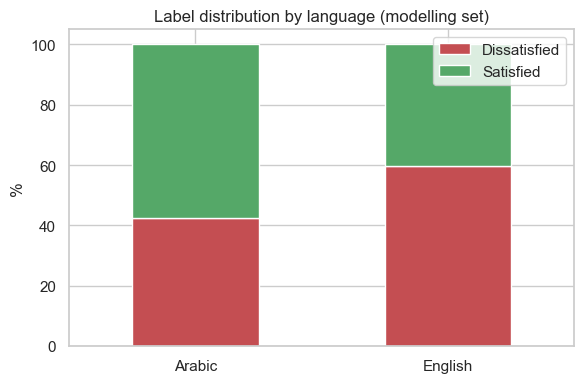

In [7]:
g = (pd.crosstab(modelling.language, modelling.satisfaction_label, normalize="index") * 100).round(1)
ax = g.plot(kind="bar", stacked=True, figsize=(6, 4), color=["#C44E52", "#55A868"])
ax.set(title="Label distribution by language (modelling set)", ylabel="%", xlabel="")
ax.legend(title=""); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / "fig_label_by_language.png", dpi=200); plt.show()

## Platform, entity and star distribution

In [8]:
print(pd.crosstab(modelling.platform, modelling.language, margins=True)); print()
stars = pd.crosstab(df.star_rating, df.satisfaction_label.fillna("Neutral"), margins=True)
print(stars); save_table(stars.reset_index(), "eda_star_by_label")

apps = (modelling.groupby("app_name").agg(n=("review_id", "size"),
        arabic=("language", lambda s: (s == "Arabic").sum()),
        dissatisfied_pct=("satisfaction_label", lambda s: (s == "Dissatisfied").mean() * 100))
        .sort_values("n", ascending=False).round(1))
save_table(apps.reset_index(), "eda_apps")
print(f"\napps in modelling set: {len(apps)}   top-5 share: {apps.n.head(5).sum()/len(modelling):.1%}   apps with < 30 reviews: {(apps.n < 30).sum()}")
apps.head(20)

language     Arabic  English    All
platform                           
App Store      2197     7012   9209
Google Play    9672    30049  39721
All           11869    37061  48930

satisfaction_label  Dissatisfied  Neutral  Satisfied    All
star_rating                                                
1                          28150        0          0  28150
2                           4293        0          0   4293
3                              0     4131          0   4131
4                              0        0       4706   4706
5                              0        0      33132  33132
All                        32443     4131      37838  74412

apps in modelling set: 134   top-5 share: 43.6%   apps with < 30 reviews: 59


,n,arabic,dissatisfied_pct
app_name,,,
RTA Dubai,5352,514,46.7
RTA Smart Drive,5121,1998,9.1
UAE PASS,4819,865,79.5
UAEICP,3280,1085,51.3
MOHRE,2739,522,54.3
MOI UAE,2531,1030,39.1
Dubai Police,2202,414,24.8
S'hail,1404,37,92.0
TAMM,1204,450,57.1


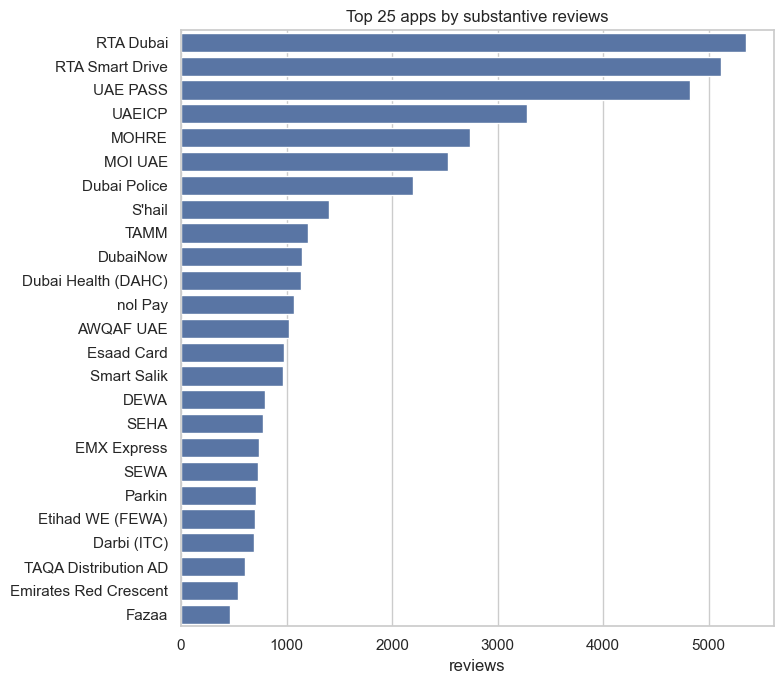

In [9]:
top = apps.head(25).reset_index()
fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=top, y="app_name", x="n", ax=ax, color="#4C72B0")
ax.set(title="Top 25 apps by substantive reviews", xlabel="reviews", ylabel="")
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / "fig_top_apps.png", dpi=200); plt.show()

## Temporal coverage

date range: 2010-04-02 to 2026-07-19
review_date
2010      22
2011      12
2012      38
2013     258
2014    1238
2015    1759
2016    2393
2017    2116
2018    1802
2019    2904
2020    4155
2021    5636
2022    4185
2023    5164
2024    6350
2025    6866
2026    4032
Name: count, dtype: int64


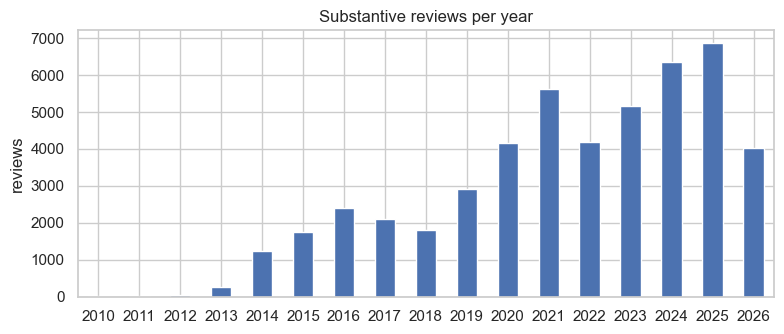

PosixPath('/Users/michaelaberra/Documents/AIML/DBA/Capstone - DA/Capstone - GIT/uae-gov-satisfaction-nlp/results/tables/eda_reviews_per_year.csv')

In [10]:
yr = modelling.review_date.dt.year.value_counts().sort_index()
print(f"date range: {modelling.review_date.min().date()} to {modelling.review_date.max().date()}")
print(yr)
ax = yr.plot(kind="bar", figsize=(8, 3.5), color="#4C72B0")
ax.set(title="Substantive reviews per year", xlabel="", ylabel="reviews"); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / "fig_reviews_per_year.png", dpi=200); plt.show()
save_table(yr.rename("n").reset_index().rename(columns={"index": "year", "review_date": "year"}), "eda_reviews_per_year")

## Aspect coverage by language (lexicon first pass)

In [11]:
cov = (modelling.groupby("language")[[f"aspect_{a}" for a in ASPECTS]].mean() * 100).round(1).T
cov.index = [i.replace("aspect_", "") for i in cov.index]
save_table(cov.reset_index().rename(columns={"index": "aspect"}), "eda_aspect_coverage_by_language")
print(f"share of substantive reviews carrying >= 1 aspect: {modelling.tagged.mean():.1%}")
cov

share of substantive reviews carrying >= 1 aspect: 56.5%


language,Arabic,English
login,2.9,11.7
payment,7.0,12.9
usability,10.3,13.5
performance,4.8,14.5
update,10.2,13.5
support,4.1,11.4
verification,4.8,4.0
notifications,2.5,1.8
language,3.0,0.8
registration,5.1,5.2


In [12]:
update_metrics("eda", {
    "word_count_mean": float(df.word_count.mean()), "word_count_median": float(df.word_count.median()),
    "length_bands": bands.to_dict(orient="records"),
    "arabic_survival": surv.to_dict(orient="records"),
    "platform_by_language": pd.crosstab(modelling.platform, modelling.language).to_dict(),
    "n_apps_modelling": int(len(apps)),
    "aspect_carrying_share_modelling": float(modelling.tagged.mean()),
    "year_counts": {int(k): int(v) for k, v in yr.items()},
})
print("metrics updated")

metrics updated
